## 준비

TensorFlow는 임포트할 때 CPU 최적화/GPU 관련 경고가 나올 수 있음.

In [2]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" #정보성 로그 끄겠다.
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0" #환경마다 결과가 미세하게 달라지는 것을 방지

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

import _ml
from _style import setup

setup()

SEED = 42
print(tf.__version__, " 준비 완료")


[폰트] Malgun Gothic / unicode_minus=False
2.21.0  준비 완료


---
## 무엇을 예측할것인가?

### 주가 방향은 쓰지 않을것이다.

머신러닝에서 "오늘 오를까?"를 예측했다. 결과는 AUC 0.5부근으로 사실상 랜덤이였다.  
신호가 없는 문제로는 **알고리즘이 잘 동작하는지조차 확인할 수 없었다.**  

그래서 이번에는 신호가 있는 문제로 변경해서 보자.

```
오늘 거래량이 최근 20일 평균보다 많을까? (거래량 급증 여부)
```

거래량은 한 번 몰리면 며칠 이어지는 성질이 있어서 **어느정도는 예측이 된다.**  
급증을 미리 감지하면 뉴스/공시를 먼저 확인할 수 있다.


In [3]:
def load_dataset():
    """
    스케일이 큰 피처 두개를 더해서 돌려주는 함수

    volume_prev, close_prev를 만들어준다.
    거래량은 수십만~수천만, 종가는 수천~수십만 단위.
    등락률은(0.0x)과 섞이면 표준편차가 억단위로 벌어진다.
    => 스케일 차이가 큰 피처
    """

    base = _ml.build_dataset().sort_values(["code", "date"])
    g = base.groupby("code")
    base["volume_prev"] = g["volume"].shift(1) #어제 거래량
    base["close_prev"] = g["close"].shift(1) #어제 종가

    # 정답생성 : 오늘거래량 > 최근 20일 평균 거래량
    raw = _ml.load_merged().sort_values(["code", "date"])
    raw["vol_ma20_prev"] = (raw.groupby("code")["volume"]
                            .transform(lambda s: s.rolling(20).mean().shift(1)))
    raw["surge"] = (raw["volume"] > raw["vol_ma20_prev"]).astype("int8")

    df = base.merge(raw[["code", "date", "surge"]], on=["code", "date"], how="left")
    return df.dropna(subset=["volume_prev", "close_prev", "surge"]).reset_index(drop=True)

FEATURES = _ml.FEATURES + ["volume_prev", "close_prev"]

df = load_dataset()
print(f"데이터 {len(df):,}행, 피처{len(FEATURES)}개")
print(f"급증 비율 : {df['surge'].mean():.3f}")
print("\n피처 : ", FEATURES)

데이터 87,360행, 피처9개
급증 비율 : 0.366

피처 :  ['ret_1d', 'ret_5d', 'ma5_ratio', 'ma20_ratio', 'vol20', 'volume_ratio', 'range_pct', 'volume_prev', 'close_prev']


In [4]:
# 시계열 데이터는 시간순으로 분할
train, test, cutoff = _ml.time_split(df, test_ratio=0.2)

X_train = train[FEATURES].to_numpy("float32")
y_train = train["surge"].to_numpy("float32")
X_test = test[FEATURES].to_numpy("float32")
y_test = test["surge"].to_numpy("float32")

print(f"분할 기준일 : {cutoff.date()}")
print(f"학습 : {X_train.shape}  검증 : {X_test.shape}")

scale = pd.DataFrame({
    "평균" : X_train.mean(axis=0),
    "표준편차" : X_train.std(axis=0),
    "최대" : X_train.max(axis=0),
}, index=FEATURES)

print()

print(scale.to_string(float_format=lambda v: f"{v:>18,.4f}"))
print(f"\n표준편차 최대/최소 = {scale['표준편차'].max() / scale['표준편차'].min():,.0f} 배 차이")

분할 기준일 : 2026-01-16
학습 : (69960, 9)  검증 : (17400, 9)

                             평균               표준편차                 최대
ret_1d                  -0.0003             0.0263             0.2755
ret_5d                  -0.0014             0.0613             0.4257
ma5_ratio                0.9989             0.0298             1.2395
ma20_ratio               0.9950             0.0687             1.4317
vol20                    0.0243             0.0101             0.0677
volume_ratio             1.0016             0.9528            15.5041
range_pct                0.0435             0.0204             0.3370
volume_prev        577,769.7500     1,555,611.6250    71,626,144.0000
close_prev          46,903.8867        59,168.6992       552,685.0000

표준편차 최대/최소 = 154,746,496 배 차이


표준편차가 1억배 이상 차이나는 상태로 신경망에 입력하면, 거대 피처가 기울기 계산을 독점한다  
-> 학습이 제대로 되지 않기떄문에 표준화 또는 정규화의 전처리가 필수적이다.

---
## 딥러닝 3단계 : 정의 -> 컴파일 -> 학습

1. 정의 : 어떤 층을 어떻게 쌓을 것인가?  
2. 컴파일 : 무엇을 최소화하고 어떻게 할습할 것인가?  
3. 학습 : 데이터를 넣고 반복  

Keras(API)를 사용하면 전부 통일된 형태로 간단하게 구현이 가능하다.

In [5]:
def build_model(n_features, hidden=(64, 32), dropout=0.0):
    """
    이진 분류용 신경망 만들기.
    hidden : 은닉층 뉴런수
    dropout : 0보다 크면 각 은닉층 뒤에 Dropout을 넣는다.
    """

    # 가중치 초기값을 고정해서 동일한 데이터로 실습할 수 있게 하자.
    tf.keras.utils.set_random_seed(SEED)

    layers = [Input(shape=(n_features,))] #피처가 몇개인지
    for units in hidden:
        layers.append(Dense(units, activation="relu"))
        if dropout > 0:
            layers.append(Dropout(dropout))
    layers.append(Dense(1, activation="sigmoid")) #이진분류 -> 출력 1개 + Sigmoid

    model = Sequential(layers)

    model.compile(
        optimizer="adam", #학습률을 알아서 조절해준다.
        loss="binary_crossentropy", #손실함수 -> 오차를 측정하는 기준 : Sigmoid와 짝
        metrics=["accuracy"], #사람이 보려고 함께 계산
    )

    return model

model = build_model(len(FEATURES))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

 **Total params: 2,753 ?**  

 Dense 층의 파라미터는 (입력개수 * 뉴런개수) + 뉴련개수(편향).   
 dense_3    9 x 64 + 64 = 640  
 dense_4    64 x 32 + 32 = 2,080  
 dense_5    32 x 1 + 1 = 33  
 = 2,753  
   
Dense(64) 한줄로 가중치 576개와 편향 64개를 알아서 만든것이다.  
학습에 실제로 쓰이는 행은 검증용 20%를 제외한 값이다.

### 학습 곡선을 그리는 함수

In [9]:
def plot_history(hist, title, ax=None, ylim=None):
    """
    학습 곡선을 그리기

    train(loss)과 validation(val_loss) 두개를 겹처 그리는 차트.
    -> 과적합 여부를 알 수 있다.
    """

    if ax is None:
        _, ax = plt.subplots(figsize=(7,3.6))

    # loss: 훈련 데이터 오차
    # val_loss: 검증 데이터의 오차
    ax.plot(hist.history["loss"], label="train", lw=1.6)
    ax.plot(hist.history["val_loss"], label="validation", lw=1.6)

    #검증 손실이 가장 낮았던 지점 => EarlyStopping지점
    best = int(np.argmin(hist.history["val_loss"]))
    ax.axvline(best, color="gray", ls=":", lw=1)
    ax.text(best, ax.get_ylim()[1], f" val_loss 최저 {best + 1}에포크",
            fontsize=8, color="gray", va="top")

    ax.set(xlabel="에포크", ylabel="손실", title=title)
    if ylim:
        ax.set_ylim(*ylim)    
    ax.legend()
    return ax

def evaluate(name, model, X, y, scaler=None):
    """테스트 셋 성능을 한줄로 출력."""
    Xe = scaler.transform(X) if scaler is not None else X
    prob = model.predict(Xe, verbose=0).ravel()
    auc = roc_auc_score(y, prob)
    acc = accuracy_score(y, (prob >= 0.5).astype(int))
    print(f"{name:<28} AUC {auc:.4f}  정확도 {acc:.4f}")
    return auc
    

---
## 스케일링 없이 학습

원본 피처를 그대로 학습. 거래량은 수천만, 등락률은 0.0x이다.

In [7]:
t0 = time.time()

model_raw = build_model(len(FEATURES))
hist_raw = model_raw.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2,   # 뒤쭉 20%는 검증용으로 뗀다
    shuffle=False,          # 섞지 않는다(시계열)
    verbose=0,              # 에포크마다 출력하면 20줄이 나온다. -> 출력을 끈다.
)

print(f"학습시간 : {time.time() - t0:.0f}초\n")
print("epoch    train_loss  val_loss")
for i in range(0,20,2):
    print(f"{i + 1:>5}  {hist_raw.history['loss'][i]:>10.1f}    {hist_raw.history['val_loss'][i]:>12.1f}")


학습시간 : 6초

epoch    train_loss  val_loss
    1      4849.3         12682.7
    3      2959.5          7474.9
    5      1576.5          1363.5
    7       791.7           448.4
    9       749.3          2031.2
   11      1951.0          4755.4
   13       985.3           713.5
   15      1467.1          7881.3
   17      1554.3          4386.4
   19       534.1          1256.0


Epoch 7까지 정상적으로 수렴  

Epoch 9이후 손실값이 안정적으로 수렴하지 못하고 크게 튀어 오른다.  
특히 Epoch 15에서는 과적합이 심각하게 나타난다.

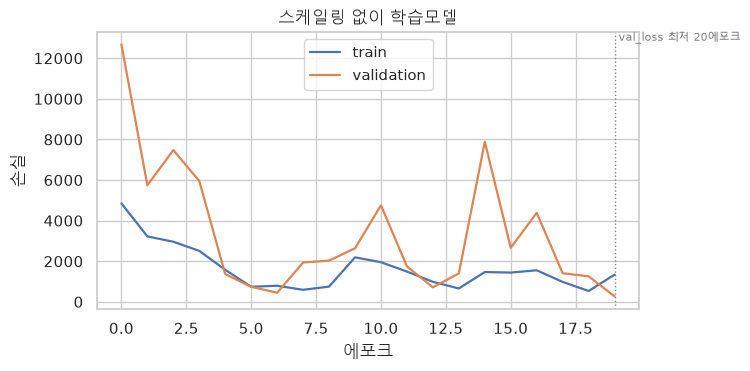

스케일링 없이 학습모델                 AUC 0.5019  정확도 0.4974

 전부 '급증아님' 으로 찍었을 때의 정확도 :  0.6302
AUC 0.50 = 랜덤찍기랑 다를바가 없다. 모델이 아무것도 학습을 하지 못한상태.


In [14]:
plot_history(hist_raw, "스케일링 없이 학습모델")
plt.show()

evaluate("스케일링 없이 학습모델", model_raw, X_test, y_test)
print(f"\n 전부 '급증아님' 으로 찍었을 때의 정확도 :  {1 - y_test.mean():.4f}")
print("AUC 0.50 = 랜덤찍기랑 다를바가 없다. 모델이 아무것도 학습을 하지 못한상태.")


손실 = 모델의 예측값과 실제값이 얼마나 차이가 나는가?  

그래프와 값을 보면 손싱은 수천단위가 나온다.  

binary_crossentropy의 기본값이 0.69근처에서 시작함.  
학습 전 모델은 아무것도 모르는 상태니까 전부 0.5로 찍는 셈인데, 그떄의 손실이 ln(2) ≈ 0.693 이기때문이다.  
여기서는 3,000에서 시작해서 위아래 튀게된다.  

거래량(수천만)에 가중치를 곱한값이 그대로 Sigmoid에 들어가면 출력이 0 또는 1로 포화된다.  
그러면 손실이 폭발하고, 역전파로 오는 수정량도 함게 폭발해서 가중치가 튄다.

=> 0.69점을 기준으로 오차범위를 조절해 나가야하는데 모델에 입력되는 숫자 자체가 너무 크다.
   너무 큰 숫자가 들어오다보니,  결과를 0~1사이로 예쁘게 잡아주지못하고 0또는 1로 굳어버린다.

---
## 스케일링 후 학습

StandardScaler로 모든 피처를 평균0, 표준편차 1로 맞춘다.

In [15]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(pd.DataFrame({"평균" : X_train_s.mean(axis=0).round(3),
                    "표준편차" : X_train_s.std(axis=0).round(3)},
                    index=FEATURES).to_string())

               평균  표준편차
ret_1d       -0.0   1.0
ret_5d       -0.0   1.0
ma5_ratio    -0.0   1.0
ma20_ratio   -0.0   1.0
vol20         0.0   1.0
volume_ratio -0.0   1.0
range_pct     0.0   1.0
volume_prev  -0.0   1.0
close_prev    0.0   1.0


In [17]:
t0 = time.time()

model_scaled = build_model(len(FEATURES))
hist_scaled = model_scaled.fit(
    X_train_s, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2,   # 뒤쭉 20%는 검증용으로 뗀다
    shuffle=False,          # 섞지 않는다(시계열)
    verbose=0,              # 에포크마다 출력하면 20줄이 나온다. -> 출력을 끈다.
)

print(f"학습시간 : {time.time() - t0:.0f}초\n")
print("epoch    train_loss  val_loss")
for i in range(0,20,2):
    print(f"{i + 1:>5}  {hist_scaled.history['loss'][i]:>10.4f}    {hist_scaled.history['val_loss'][i]:>10.4f}")


학습시간 : 5초

epoch    train_loss  val_loss
    1      0.6504        0.6422
    3      0.6280        0.6334
    5      0.6243        0.6315
    7      0.6226        0.6304
    9      0.6214        0.6298
   11      0.6206        0.6294
   13      0.6198        0.6294
   15      0.6193        0.6293
   17      0.6189        0.6293
   19      0.6185        0.6292


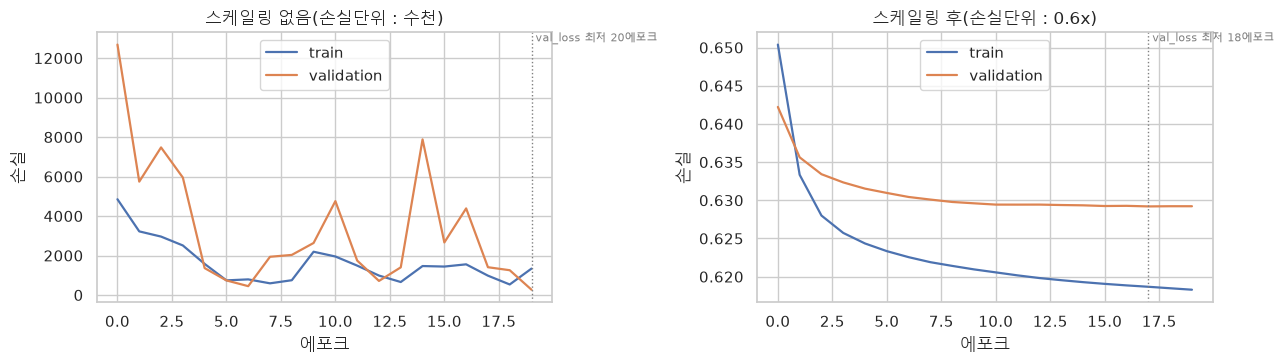

스케일링 없음                      AUC 0.5019  정확도 0.4974
스케일링 후                       AUC 0.6223  정확도 0.6286

 같은 모델, 같은 시드, 같은 데이터의 스케일링 차이 AUC 0.502 -> 0.622


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
plot_history(hist_raw, "스케일링 없음(손실단위 : 수천)", ax=axes[0])
plot_history(hist_scaled, "스케일링 후(손실단위 : 0.6x)", ax=axes[1])
plt.tight_layout()
plt.show()

auc_raw =  evaluate("스케일링 없음", model_raw, X_test, y_test)
auc_scaled = evaluate("스케일링 후", model_scaled, X_test, y_test, scaler)
print(f"\n 같은 모델, 같은 시드, 같은 데이터의 스케일링 차이 AUC {auc_raw:.3f} -> {auc_scaled:.3f}")


스케일링은 단순히 성능을 조금 올려주는게 아니라  
신경망 자체가 동작하느냐 마느냐의 문제다. -> 항상 Pipeline으로 묶어서 사용.

## 히스토리 읽는법

|모양|상태|할일|
|---|---|---|
|둘다 내려가는 중|학습이 되는 중|에포크를 늘림|
|둘다 낮고 붙어있음|학습완료상태|그대로사용|
|train은 내려가는데 val은 올라감|과적합|학습멈춤|
|둘다 높고 안내려감|과소적합, 학습데이터/피처 부족|스케일링 확인 -> 모델 키워기 -> 피처추가|

---
## Dropout 없이 크게 학습 -> 과적합

에포크도 20 -> 60으로 키우고, 은닉층 256 -> 256 -> 128으로 키워서 돌려보자.  

우리가 사용하는 학습데이터는 대략 6만개정도인데 파라미터는 10만개가 넘는다.  
> 파라미터가 데이터보다 많으면 매우매우매우매우매우 높은 확률로 과적합된다.

In [19]:
t0 = time.time()

model_big = build_model(len(FEATURES), hidden=(256,256,128), dropout=0.0)
print(f"{model_big.count_params():,}개 / 학습데이터 {int(len(X_train) * 0.8):,}행\n")

hist_big = model_big.fit(
    X_train_s, y_train,
    epochs=60,
    batch_size=512,
    validation_split=0.2,   # 뒤쭉 20%는 검증용으로 뗀다
    shuffle=False,          # 섞지 않는다(시계열)
    verbose=0,              # 에포크마다 출력하면 20줄이 나온다. -> 출력을 끈다.
)

print(f"학습시간 : {time.time() - t0:.0f}초\n")
print("epoch    train_loss  val_loss")
for i in range(0,20,2):
    print(f"{i + 1:>5}  {hist_big.history['loss'][i]:>10.4f}    {hist_big.history['val_loss'][i]:>10.4f}")


101,377개 / 학습데이터 55,968행

학습시간 : 27초

epoch    train_loss  val_loss
    1      0.6370        0.6327
    3      0.6234        0.6307
    5      0.6213        0.6296
    7      0.6200        0.6289
    9      0.6189        0.6289
   11      0.6177        0.6290
   13      0.6165        0.6295
   15      0.6154        0.6299
   17      0.6142        0.6305
   19      0.6128        0.6318


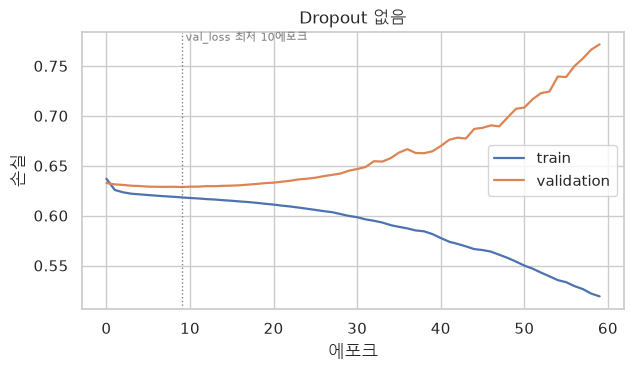

은닉층키우고 Dropout 없음            AUC 0.5945  정확도 0.6053


0.5945166916986343

In [20]:
plot_history(hist_big, "Dropout 없음")
plt.show()

evaluate("은닉층키우고 Dropout 없음", model_big, X_test, y_test, scaler)


에포크를 늘렸다니 train은 계속 내려가는데 val은 올라간다.  
두 곡선이 벌어지는 이 그림이 '과적합' 상태다.

---
## Dropout + EarlyStopping 적용

Dropout(0.3) : 학습 중 뉴런의 30%를 무작위로 끈다 -> 특정 뉴런에 의존하지 못하게  
EarlyStopping : patience값 만큼 참고 이 값이 넘어가도 검증 손실이 나아지지 않으면 멈춘다.

In [22]:
es = EarlyStopping(
    monitor="val_loss",   # 무엇을 볼것인가?
    patience=8,           # 몇번 참을 것인가?
    restore_best_weights=True, #참기 전 가장 좋았던 시점으로 되돌린다.
)

t0 = time.time()

model_drop = build_model(len(FEATURES), hidden=(256,256,128), dropout=0.3)
print(f"{model_drop.count_params():,}개 / 학습데이터 {int(len(X_train) * 0.8):,}행\n")

hist_drop = model_drop.fit(
    X_train_s, y_train,
    epochs=60,
    batch_size=512,
    validation_split=0.2,   # 뒤쭉 20%는 검증용으로 뗀다
    shuffle=False,          # 섞지 않는다(시계열)
    verbose=0,              # 에포크마다 출력하면 20줄이 나온다. -> 출력을 끈다.
    callbacks=[es],
)

ran = len(hist_drop.history["loss"])
best = int(np.argmin(hist_drop.history["val_loss"])) + 1

print(f"반복 횟수 : {ran}  멈춘지점 : {best}")

print(f"학습시간 : {time.time() - t0:.0f}초\n")
print("epoch    train_loss  val_loss")
for i in range(0,20,2):
    print(f"{i + 1:>5}  {hist_drop.history['loss'][i]:>10.4f}    {hist_drop.history['val_loss'][i]:>10.4f}")


101,377개 / 학습데이터 55,968행

반복 횟수 : 21  멈춘지점 : 13
학습시간 : 12초

epoch    train_loss  val_loss
    1      0.6440        0.6324
    3      0.6267        0.6291
    5      0.6256        0.6289
    7      0.6238        0.6281
    9      0.6224        0.6278
   11      0.6221        0.6277
   13      0.6215        0.6275
   15      0.6208        0.6277
   17      0.6201        0.6282
   19      0.6198        0.6282


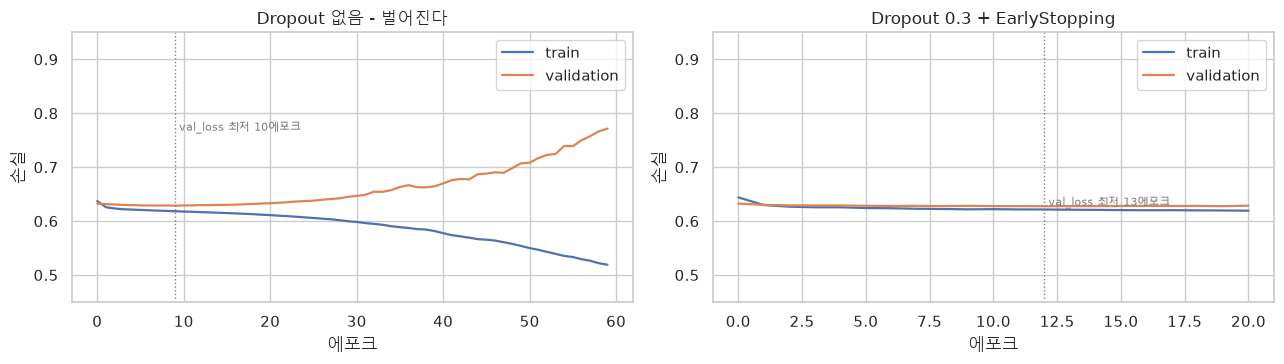

같은 크기의 모델
Dropout 없음                   AUC 0.5945  정확도 0.6053
Dropout 0.3 + EarlyStopping  AUC 0.6239  정확도 0.6302


0.6238779460393687

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
plot_history(hist_big, "Dropout 없음 - 벌어진다", ax=axes[0], ylim=(0.45, 0.95))
plot_history(hist_drop, "Dropout 0.3 + EarlyStopping", ax=axes[1], ylim=(0.45, 0.95))
plt.tight_layout()
plt.show()

print("같은 크기의 모델")
evaluate("Dropout 없음", model_big, X_test, y_test, scaler)
evaluate("Dropout 0.3 + EarlyStopping", model_drop, X_test, y_test, scaler)



---
## 출력층과 손실함수는 짝이다

출력층과 손실함수는 문제 유형이 결정한다.
|문제|출력층|손실함수|
|---|---|---|
|이진분류|Dense(1, activation="sigmoid")|binary_crossentropy|
|다중분류|Dense(N, activation="softmax")|categorical_crossentropy|
|회귀|Dense(1)| mse |

---
## 모델 저장

Keras모델은 joblib이 아니라 model.save()를 사용한다.

In [24]:
import joblib
from tensorflow.keras.models import load_model

from _config import model_path, MODEL_DIR

model_drop.save(model_path("surge_nn.keras")) #keras모델 저장
joblib.dump(scaler, model_path("surge_scaler.pkl")) #스케일러 따로 저장
joblib.dump(FEATURES, model_path("surge_features.pkl")) #피처 순서 저장

for f in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
    print(f"{f}({size:.1f}KB)")

surge_features.pkl(0.1KB)
surge_nn.keras(1224.3KB)
surge_scaler.pkl(0.8KB)


In [27]:
# 다시 불러와서 사용해보기
loaded_model = load_model(model_path("surge_nn.keras"))
loaded_scaler = joblib.load(model_path("surge_scaler.pkl"))
loaded_features = joblib.load(model_path("surge_features.pkl"))

raw_input = test[loaded_features].to_numpy("float32")[:5]

before = model_drop.predict(scaler.transform(raw_input), verbose=0).ravel()
after = loaded_model.predict(loaded_scaler.transform(raw_input), verbose=0).ravel()

print("저장 전 : ", before.round(6))
print("불러온 후 : ", after.round(6))

저장 전 :  [0.382553 0.316227 0.381286 0.29414  0.440522]
불러온 후 :  [0.382553 0.316227 0.381286 0.29414  0.440522]


함께 저장해야 하는 것  
모델 + 스케일러 + 피처목록/순서